# EDA
## merge des exports issus de la Data prep

Notebooks de Data prep :
- bdiff.ipynb
- communes.ipynb

Etapes de l'EDA :
- import des incendies et des communes en .parquet
- jointure
- analyse

In [33]:
import sys
from pathlib import Path

from IPython.display import HTML, display

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import seaborn as sns
import geopandas as gpd
import folium
from folium.plugins import HeatMap, MarkerCluster
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import HTML, IFrame, display
import base64


# adds parent file of the current directory
# to the paths in which Python looks for modules to import
# in the current Python process
sys.path.append(str(Path.cwd().parent))

from src.config import BDIFF_RAW_DIR, BDIFF_CLEAN_DIR, GEO_DATA_CLEAN_DIR, ROOT_DIR, FIGURES_DIR
from utils.cleaning_utils import delete, normalize_columns_names, normalize_text_columns_cells, optimize_numeric_column, fill_rate
from utils.analysis_utils import plot_missing_bar, plot_numeric_histograms, plot_corr_heatmap, plot_qualitative

In [2]:
df_incendies = pd.read_parquet(
    BDIFF_CLEAN_DIR / "incendies.parquet"
)

df_communes = pd.read_parquet(
    GEO_DATA_CLEAN_DIR / "communes_metropole_corse.parquet"
)

### CONSTANTES CARTOGRAPHIQUE
Centrage sur la France métropolitaine

In [ ]:
LAT_MIN, LAT_MAX = 41.3, 51.1
LON_MIN, LON_MAX = -5.5, 9.8

MAP_CENTER = [46.5, 2.5]
MAP_ZOOM = 6


Paramétrage de l'affichage des cartes

In [23]:

FIRE_GRADIENT = { 
    # Orange clair (faible densité)
    0.2: '#ffaa00', 
    # Orange vif (densité moyenne) 
    0.5: '#ff5500', 
    # Violet / Pourpre (forte densité) 
    0.8: '#9900cc',  
    # Violet très foncé / Indigo (très forte densité) 
    1.0: '#4b0082' 
    }

HEATMAP_CONFIG = {
     'radius': 10, 
     'blur': 10, 
     # Conserve la visibilité des points au zoom 
     'min_opacity': 0.85, 
     # Maintient l'intensité jusqu'au zoom maximal 
     'max_zoom': 18, 
     'gradient': FIRE_GRADIENT 
    }

TILES_SERVER = {
    "OpenStreetMap": {
        'tiles' : 'OpenStreetMap',
        'attr': None
    },
    'Esri Satellite': {
        'tiles' : 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
        'attr': 'Esri World imagery'
    },
    'CartDB Voyager': {
        'tiles' : 'https://{s}.basemaps.cartocdn.com/rastertiles/voyager/{z}/{x}/{y}{r}.png',
        'attr': 'CARTO'
    },
    'OpenTopoMap': {
        'tiles' : 'https://{s}.tile.opentopomap.org/{z}/{x}/{y}.png',
        'attr': 'OpenTopoMap'
    }
}

MAP_TITLE_TEMPLATE ="""
<div style="
    position: fixed; 
    top: 12px; 
    left: 60px; 
    z-index: 9999; 
    font-family: 'Helvetica Neue', Arial, sans-serif; 
    font-size: 16px;
    font-weight: 700;
    color: darkorange;
    background-color: rgba(255, 255, 255, 0.85); 
    padding: 8px 14px; 
    border-radius: 6px; 
    box-shadow: 0 2px 6px rgba(0,0,0,0.2); 
    border: 1px solid #cccccc; 
"> 
    {title}
</div>
"""

def add_map_title(map_object, title):
    """Add a title to a folium map object."""
    title_html = MAP_TITLE_TEMPLATE.format(title=title)
    map_object.get_root().html.add_child(folium.Element(title_html))


In [4]:
df_incendies.head(2)

,departement,code_insee,date_de_premiere_alerte,surface_parcourue_m2,surface_foret_m2,surface_maquis_garrigues_m2,autres_surfaces_naturelles_hors_foret_m2,surfaces_agricoles_m2,autres_surfaces_m2,surface_autres_terres_boisees_m2,surfaces_non_boisees_naturelles_m2,surfaces_non_boisees_artificialisees_m2,surfaces_non_boisees_m2,type_de_peuplement,nature
0,2a,2a198,2011-01-01 00:33:00,50,24,24,0,<NA>,<NA>,<NA>,<NA>,<NA>,2,1,involontaire (particulier)
1,11,11203,2011-01-02 09:10:00,1,1,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0,4,NaN


In [5]:
df_communes.head(2)

,code_insee,localisation,nom_standard,region,departement,population,superficie_hectare,densite,altitude_moyenne,altitude_minimale,altitude_maximale,latitude,longitude,grille_densite
0,01001,1400,L'Abergement-Clémenciat,84,01,860,1562,55.060001,242,206,272,46.151,4.921,6
1,01002,1640,L'Abergement-de-Varey,84,01,270,918,29.43,483,290,748,46.007,5.423,6


#### Fusion des dataset incendies/BDIFF et liste des communes/data.gouv.fr
sur la clé code_insee

In [6]:
df = df_incendies.merge(
    df_communes,
    on="code_insee",
    how="left"
)

In [7]:
df.head(2)

,departement_x,code_insee,date_de_premiere_alerte,surface_parcourue_m2,surface_foret_m2,surface_maquis_garrigues_m2,autres_surfaces_naturelles_hors_foret_m2,surfaces_agricoles_m2,autres_surfaces_m2,surface_autres_terres_boisees_m2,...,departement_y,population,superficie_hectare,densite,altitude_moyenne,altitude_minimale,altitude_maximale,latitude,longitude,grille_densite
0,2a,2a198,2011-01-01 00:33:00,50,24,24,0,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,11,11203,2011-01-02 09:10:00,1,1,0,<NA>,<NA>,<NA>,<NA>,...,11,10343,3821,270.690002,58,19,187,43.2,2.758,2


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52806 entries, 0 to 52805
Data columns (total 28 columns):
 #   Column                                    Non-Null Count  Dtype         
---  ------                                    --------------  -----         
 0   departement_x                             52806 non-null  str           
 1   code_insee                                52806 non-null  object        
 2   date_de_premiere_alerte                   52806 non-null  datetime64[us]
 3   surface_parcourue_m2                      52806 non-null  Int32         
 4   surface_foret_m2                          48156 non-null  Int32         
 5   surface_maquis_garrigues_m2               28073 non-null  Int32         
 6   autres_surfaces_naturelles_hors_foret_m2  34531 non-null  Int32         
 7   surfaces_agricoles_m2                     6588 non-null   Int32         
 8   autres_surfaces_m2                        6572 non-null   Int32         
 9   surface_autres_terres_boisees_m2       

In [27]:
AVAILABLE_YEARS = [int(y) for y in sorted(df['annee'].dropna().unique())]

In [9]:
df['annee'] = df['date_de_premiere_alerte'].dt.year
df['mois'] = df['date_de_premiere_alerte'].dt.month
df['jours'] = df['date_de_premiere_alerte'].dt.day


In [10]:
# df['annee'].unique()
df['mois'].unique()
# df['jours'].unique()



array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

### Carte 1 — Incendies

In [31]:
m = folium.Map(location=MAP_CENTER, zoom_start=MAP_ZOOM, tiles=None)

for name, config in TILES_SERVER.items(): 
        folium.TileLayer( 
                tiles=config['tiles'], 
                attr=config['attr'], 
                name=name 
        ).add_to(m)


for year in AVAILABLE_YEARS:
    df_year = df[df['annee'] == year]
    heat_data_year = df_year[['latitude', 'longitude']].dropna().values.tolist()
    # Affiche uniquement la dernière année par défaut
    is_show= (year == max(AVAILABLE_YEARS))

    group = folium.FeatureGroup(
          name=f'{year} : ({len(heat_data_year)} feux)', 
          show=is_show
          )

    # Dépaquetage des paramètres avec **HEATMAP_CONFIG**
    HeatMap(
          heat_data_year, 
          **HEATMAP_CONFIG
          ).add_to(group)
    
    group.add_to(m) 

# 5. Sélecteur de couches 
folium.LayerControl(position='topright', 
                    collapsed=True
                    ).add_to(m)

add_map_title(m, "Répartition des incendies en France métropolitaine et Corse")

m

### Carte 2 — Intensité (Pondérée par la surface brûlée)

In [30]:
# 1. Préparation des données pondérées 
df_surf = df.dropna(subset=['latitude', 'longitude', 'surface_parcourue_m2']).copy() 
df_surf = df_surf[df_surf['surface_parcourue_m2'] > 0] 

# Transformation log et normalisation entre 0 et 1 
df_surf['weight'] = np.log1p(df_surf['surface_parcourue_m2']) 
df_surf['weight'] = df_surf['weight'] / df_surf['weight'].max() 

# Initialisation de la carte 
m_int = folium.Map(location=MAP_CENTER, zoom_start=MAP_ZOOM, tiles=None) 

# Ajout des fonds de carte 
for name, config in TILES_SERVER.items(): 
    folium.TileLayer( 
        tiles=config['tiles'], 
        attr=config['attr'], 
        name=name 
    ).add_to(m_int) 

for year in AVAILABLE_YEARS:
    df_year = df_surf[df_surf['annee'] == year]

    # Données avec poids [latitude, longitude, weight] 
    heat_data_weighted = df_year[['latitude', 'longitude', 'weight']].values.tolist()
    is_show = (year == max(AVAILABLE_YEARS))

    group = folium.FeatureGroup(
        name=f'Intensité{year} : ({len(heat_data_weighted)} feux)', 
        show=is_show
    )

    HeatMap(
        heat_data_weighted, 
        **HEATMAP_CONFIG
    ).add_to(group) 

    group.add_to(m_int) 

# 6. Sélecteur de couches 
folium.LayerControl(position='topright', collapsed=False).add_to(m_int) 

add_map_title(m_int, "Répartition des incendies selon leur intensité")

m_int

### Analyse temporelle et saisonnière

In [38]:
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Helvetica Neue, Arial, sans-serif"

#conversion de la surface en hectares (1ha = 10000 m2)
df['surface_parcourue_ha'] = df['surface_parcourue_m2'] / 10_000

MONTH_NAMES = ["Jan","Fev","Mar","Avr","Mai","Juin","Juil","Aout","Sep","Oct","Nov","Dec"]

In [39]:
# Aggregation par année
df_yearly = (
    df.groupby('annee')
    .agg(
        nb_fires=('date_de_premiere_alerte', 'count'),
        total_surface_ha=('surface_parcourue_ha', 'sum'),
        mean_surface_ha=('surface_parcourue_ha', 'mean'),
        median_surface_ha=('surface_parcourue_ha', 'median'),
    )
    .reset_index()
)

### Évolution annuelle (2011–2025)

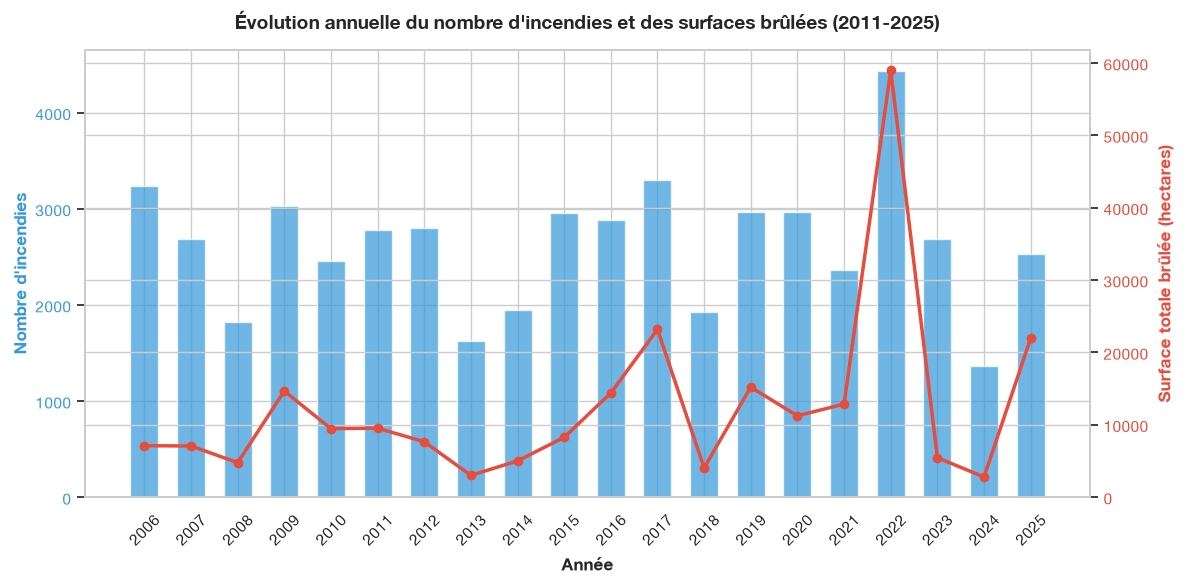

In [44]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Axe 1 : Barres du nombre d'incendies
colors_bars = "#3498db"
ax1.bar(
    df_yearly['annee'], 
    df_yearly['nb_fires'], 
    color=colors_bars, 
    alpha=0.7,
    width=0.6,
    label="Nombre d'incendies"
)
ax1.set_xlabel("Année", fontsize=12, fontweight="bold") 
ax1.set_ylabel("Nombre d'incendies", 
               color=colors_bars, 
               fontsize=12, 
               fontweight="bold") 
ax1.tick_params(axis="y", labelcolor=colors_bars) 
ax1.set_xticks(df_yearly["annee"]) 
ax1.set_xticklabels(df_yearly["annee"].astype(int), 
                    rotation=45
                    ) 
# Axe 2 : Ligne de la surface totale brulee (ha) 
ax2 = ax1.twinx() 
color_line = "#e74c3c" 
ax2.plot( 
    df_yearly["annee"], 
    df_yearly["total_surface_ha"], 
    color=color_line, marker="o", 
    linewidth=2.5, markersize=6, 
    label="Surface brûlée (ha)"
    ) 
ax2.set_ylabel( "Surface totale brûlée (hectares)", 
               color=color_line, 
               fontsize=12, 
               fontweight="bold"
               ) 
ax2.tick_params(axis="y", labelcolor=color_line) 

plt.title( 
    "Évolution annuelle du nombre d'incendies et des surfaces brûlées (2011-2025)", 
    fontsize=14, 
    fontweight="bold", 
    pad=15, ) 

plt.tight_layout()


### Saisonnalité mensuelle

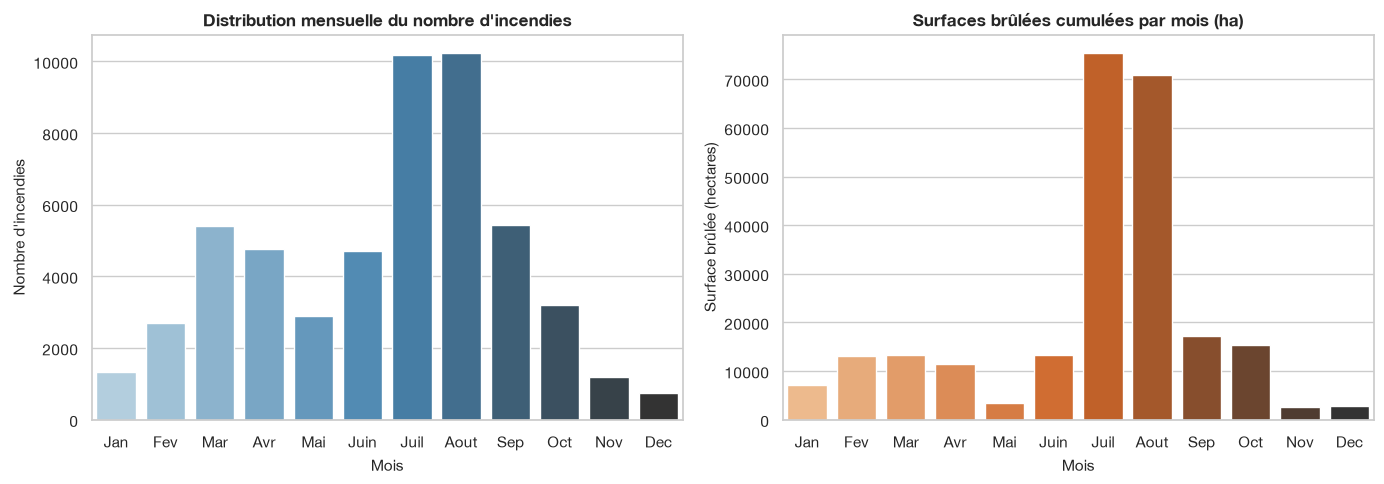

In [50]:
# Aggregation par mois 
df_mensuel = ( 
    df.groupby("mois") 
    .agg( 
        nb_incendies=("surface_parcourue_m2", "count"), 
        total_surface_ha=("surface_parcourue_ha", "sum") 
    ) 
    .reset_index() 
) 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5)) 

# 1. Nombre moyen/cumule d incendies par mois 
sns.barplot( data=df_mensuel, 
            x="mois", 
            y="nb_incendies", 
            palette="Blues_d", 
            ax=ax1, 
            hue="mois", 
            legend=False
)

ax1.set_title( "Distribution mensuelle du nombre d'incendies", fontsize=12, fontweight="bold" ) 
ax1.set_xlabel("Mois", fontsize=11) 
ax1.set_ylabel("Nombre d'incendies", fontsize=11) 
ax1.set_xticks(range(12)) 
ax1.set_xticklabels(MONTH_NAMES) 

# 2. Surface totale brulee par mois 
sns.barplot( 
    data=df_mensuel, 
    x="mois", 
    y="total_surface_ha", 
    palette="Oranges_d", 
    ax=ax2, 
    hue="mois", 
    legend=False
    ) 
ax2.set_title( "Surfaces brûlées cumulées par mois (ha)", fontsize=12, fontweight="bold" ) 
ax2.set_xlabel("Mois", fontsize=11) 
ax2.set_ylabel("Surface brûlée (hectares)", fontsize=11) 
ax2.set_xticks(range(12)) 
ax2.set_xticklabels(MONTH_NAMES)

plt.tight_layout()

### Distribution des surfaces brûlées (Échelle Log)

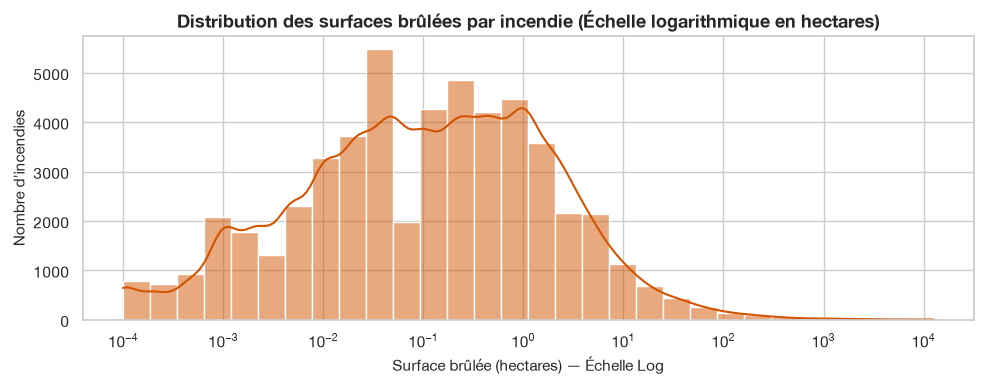

In [54]:
# Filtrage des feux avec surface > 0 
df_pos = df[df["surface_parcourue_m2"] > 0].copy() 

plt.figure(figsize=(10, 4)) 

# Distribution log-transformee 
sns.histplot( 
    data=df_pos, 
    x="surface_parcourue_ha", 
    log_scale=True, 
    color="#d35400", 
    kde=True, 
    bins=30, 
) 

plt.title( "Distribution des surfaces brûlées par incendie (Échelle logarithmique en hectares)", 
          fontsize=13, 
          fontweight="bold"
) 
plt.xlabel("Surface brûlée (hectares) — Échelle Log", fontsize=11) 
plt.ylabel("Nombre d'incendies", fontsize=11) 
plt.tight_layout()